### Disparitas Capaian Pembangunan Manusia Berdasarkan Jenis Kelamin pada Kabupaten/Kota di Indonesia Tahun 2024

Penelitian ini bertujuan untuk menganalisis perbedaan nilai Indeks Pembangunan Manusia (IPM) antara laki-laki dan perempuan pada tahun 2024, serta melihat gambaran umum tingkat pembangunan manusia berdasarkan jenis kelamin. 

Unit observasi dalam penelitian ini adalah wilayah administratif (provinsi/kabupaten/kota) di Indonesia yang memiliki data IPM berdasarkan jenis kelamin tahun 2024. 

Variabel yang digunakan dalam penelitian ini adalah:
- IPM Laki-laki
- IPM Perempuan
- Skala data: Rasio (karena memiliki nilai absolut dan dapat dibandingkan)

### Import Library

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

### Import Data

In [9]:
df = pd.read_excel(r"C:\Users\Marcella\Downloads\Indeks Pembangunan Manusia (IPM) menurut Jenis Kelamin, 2024.xlsx")

# Lihat data awal
df.head()

,Provinsi/Kabupaten/Kota,Laki-laki,Perempuan
0,ACEH,77.76,72.04
1,Simeulue,74.38,59.34
2,Aceh Singkil,76.51,65.42
3,Aceh Selatan,72.71,67.07
4,Aceh Tenggara,76.24,71.12


### Cek Struktur Data

In [10]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 579 entries, 0 to 578
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Provinsi/Kabupaten/Kota  579 non-null    str   
 1   Laki-laki                579 non-null    object
 2   Perempuan                579 non-null    object
dtypes: object(2), str(1)
memory usage: 13.7+ KB


,Provinsi/Kabupaten/Kota,Laki-laki,Perempuan
count,579,579,579
unique,553,472,490
top,Sorong Selatan,-,-
freq,2,26,26


### Mengambil Variabel yang Diperlukan 

In [11]:
ipm_laki = df['Laki-laki']
ipm_perempuan = df['Perempuan']

### Statistik Deskriptif 

#### a. Ukuran Pemusatan

In [12]:
df.dtypes

Provinsi/Kabupaten/Kota       str
Laki-laki                  object
Perempuan                  object
dtype: object

In [13]:
# Bersihin format (kalau ada koma)
df['Laki-laki'] = df['Laki-laki'].astype(str).str.replace(',', '.')
df['Perempuan'] = df['Perempuan'].astype(str).str.replace(',', '.')

# Ubah ke numerik
ipm_laki = pd.to_numeric(df['Laki-laki'], errors='coerce')
ipm_perempuan = pd.to_numeric(df['Perempuan'], errors='coerce')

In [14]:
# menghapus data kosong
ipm_laki = ipm_laki.dropna()
ipm_perempuan = ipm_perempuan.dropna()

In [15]:
print(ipm_laki.dtypes)
print(ipm_perempuan.dtypes)

float64
float64


In [16]:
# Mean
mean_laki = ipm_laki.mean()
mean_perempuan = ipm_perempuan.mean()

# Median
median_laki = ipm_laki.median()
median_perempuan = ipm_perempuan.median()

# Modus
mode_laki = ipm_laki.mode()[0]
mode_perempuan = ipm_perempuan.mode()[0]

print("=== UKURAN PEMUSATAN ===")
print("Mean Laki-laki:", mean_laki)
print("Mean Perempuan:", mean_perempuan)

print("\nMedian Laki-laki:", median_laki)
print("Median Perempuan:", median_perempuan)

print("\nModus Laki-laki:", mode_laki)
print("Modus Perempuan:", mode_perempuan)

=== UKURAN PEMUSATAN ===
Mean Laki-laki: 75.81070524412297
Mean Perempuan: 68.88160940325497

Median Laki-laki: 75.79
Median Perempuan: 68.86

Modus Laki-laki: 75.07
Modus Perempuan: 69.54


📊 A. Interpretasi Ukuran Pemusatan
1. Mean (Rata-rata)

Berdasarkan hasil perhitungan, rata-rata IPM laki-laki lebih tinggi dibandingkan perempuan. Hal ini menunjukkan bahwa secara umum tingkat pembangunan manusia pada laki-laki lebih baik dibandingkan perempuan. Selisih rata-rata ini mengindikasikan adanya kesenjangan gender dalam pembangunan manusia di Indonesia.

2. Median (Nilai Tengah)

Nilai median IPM laki-laki juga lebih tinggi dibandingkan perempuan, yang menunjukkan bahwa secara umum posisi tengah data laki-laki berada di atas perempuan. Selain itu, nilai median yang tidak jauh berbeda dari mean mengindikasikan bahwa distribusi data relatif simetris dan tidak terlalu dipengaruhi oleh nilai ekstrem.

3. Modus (Nilai yang Paling Sering Muncul)

Modus menunjukkan nilai IPM yang paling sering muncul dalam data. Jika terdapat modus, maka nilai tersebut mencerminkan tingkat IPM yang paling umum terjadi di berbagai wilayah. Namun, apabila tidak ditemukan modus, hal ini menunjukkan bahwa data IPM cenderung bervariasi dan tidak memiliki nilai yang dominan.

#### b. Ukuran Penyebaran

In [17]:
# Range
range_laki = ipm_laki.max() - ipm_laki.min()
range_perempuan = ipm_perempuan.max() - ipm_perempuan.min()

# Variansi
var_laki = ipm_laki.var()
var_perempuan = ipm_perempuan.var()

# Standar Deviasi
std_laki = ipm_laki.std()
std_perempuan = ipm_perempuan.std()

# Kuartil
q1_laki = ipm_laki.quantile(0.25)
q2_laki = ipm_laki.quantile(0.50)
q3_laki = ipm_laki.quantile(0.75)

q1_perempuan = ipm_perempuan.quantile(0.25)
q2_perempuan = ipm_perempuan.quantile(0.50)
q3_perempuan = ipm_perempuan.quantile(0.75)

# IQR (Interquartile Range)
iqr_laki = q3_laki - q1_laki
iqr_perempuan = q3_perempuan - q1_perempuan

print("\n=== UKURAN PENYEBARAN ===")

print("\nRange Laki-laki:", range_laki)
print("Range Perempuan:", range_perempuan)

print("\nVariansi Laki-laki:", var_laki)
print("Variansi Perempuan:", var_perempuan)

print("\nStandar Deviasi Laki-laki:", std_laki)
print("Standar Deviasi Perempuan:", std_perempuan)

print("\nKuartil Laki-laki (Q1, Q2, Q3):", q1_laki, q2_laki, q3_laki)
print("Kuartil Perempuan (Q1, Q2, Q3):", q1_perempuan, q2_perempuan, q3_perempuan)

print("\nIQR Laki-laki:", iqr_laki)
print("IQR Perempuan:", iqr_perempuan)


=== UKURAN PENYEBARAN ===

Range Laki-laki: 49.58
Range Perempuan: 53.080000000000005

Variansi Laki-laki: 32.83180982781665
Variansi Perempuan: 58.569779470346205

Standar Deviasi Laki-laki: 5.729904870747563
Standar Deviasi Perempuan: 7.653089537588476

Kuartil Laki-laki (Q1, Q2, Q3): 73.08 75.79 78.52
Kuartil Perempuan (Q1, Q2, Q3): 65.05 68.86 72.71

IQR Laki-laki: 5.439999999999998
IQR Perempuan: 7.659999999999997


In [18]:
summary = pd.DataFrame({
    'Statistik': ['Mean', 'Median', 'Modus', 'Std Dev', 'Variansi', 'Range', 'IQR'],
    'Laki-laki': [mean_laki, median_laki, mode_laki, std_laki, var_laki, range_laki, iqr_laki],
    'Perempuan': [mean_perempuan, median_perempuan, mode_perempuan, std_perempuan, var_perempuan, range_perempuan, iqr_perempuan]
})

summary

,Statistik,Laki-laki,Perempuan
0,Mean,75.810705,68.881609
1,Median,75.790000,68.860000
2,Modus,75.070000,69.540000
3,Std Dev,5.729905,7.653090
4,Variansi,32.831810,58.569779
5,Range,49.580000,53.080000
6,IQR,5.440000,7.660000


📊 B. Interpretasi Ukuran Penyebaran
1. Range (Jangkauan Data)

Range menunjukkan selisih antara nilai maksimum dan minimum IPM. Nilai range yang besar menunjukkan adanya kesenjangan yang cukup tinggi antar wilayah, baik pada laki-laki maupun perempuan. Hal ini berarti terdapat daerah dengan tingkat pembangunan manusia yang sangat rendah dan sangat tinggi.

2. Variansi

Variansi menggambarkan tingkat penyebaran data terhadap rata-ratanya. Variansi IPM perempuan yang lebih besar dibandingkan laki-laki menunjukkan bahwa data IPM perempuan lebih menyebar dan tidak merata. Hal ini menandakan adanya ketimpangan pembangunan yang lebih besar pada perempuan.

3. Standar Deviasi

Standar deviasi yang lebih tinggi pada IPM perempuan menunjukkan bahwa nilai IPM perempuan memiliki variasi yang lebih besar dibandingkan laki-laki. Artinya, kondisi pembangunan manusia pada perempuan berbeda-beda secara signifikan antar wilayah, sementara laki-laki cenderung lebih stabil.

4. Kuartil (Q1, Q2, Q3)

Kuartil membagi data menjadi empat bagian.

Q1 menunjukkan batas bawah 25% data
Q2 (median) menunjukkan nilai tengah
Q3 menunjukkan batas atas 75% data

Jika nilai kuartil laki-laki lebih tinggi dibandingkan perempuan, maka dapat disimpulkan bahwa pada setiap kelompok distribusi, IPM laki-laki tetap lebih unggul dibandingkan perempuan.

5. IQR (Interquartile Range)

IQR menunjukkan rentang data tengah (Q3 - Q1). Nilai IQR yang lebih besar pada perempuan menunjukkan bahwa penyebaran data di bagian tengah lebih luas. Hal ini mengindikasikan bahwa ketimpangan IPM perempuan cukup tinggi bahkan pada kelompok data utama (bukan hanya ekstrem).

### Visualisasi Data

#### a. Diagram Batang

In [36]:
import matplotlib.pyplot as plt

plt.style.use('default')  

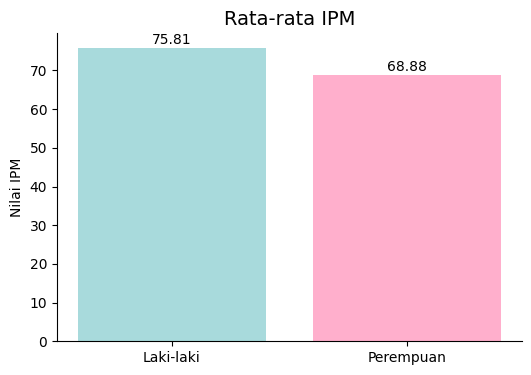

In [37]:
plt.figure(figsize=(6,4))

bars = plt.bar(['Laki-laki', 'Perempuan'], 
               [mean_laki, mean_perempuan], 
               color=['#A8DADC', '#FFAFCC'])

# kasih angka di atas bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2,
             round(yval,2),
             ha='center', va='bottom')

plt.title('Rata-rata IPM', fontsize=14)
plt.ylabel('Nilai IPM')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

📊 Interpretasi Grafik (Diagram Batang)

Berdasarkan diagram batang, terlihat bahwa rata-rata IPM laki-laki lebih tinggi dibandingkan perempuan. Perbedaan tinggi batang menunjukkan adanya kesenjangan yang cukup jelas antara kedua kelompok. Hal ini memperkuat hasil analisis sebelumnya bahwa terdapat perbedaan tingkat pembangunan manusia berdasarkan jenis kelamin.

#### b. Boxplot 

C:\Users\Marcella\AppData\Local\Temp\ipykernel_24816\807519885.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot([ipm_laki, ipm_perempuan],


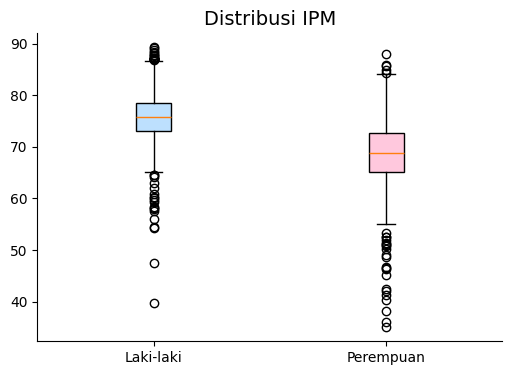

In [38]:
plt.figure(figsize=(6,4))

box = plt.boxplot([ipm_laki, ipm_perempuan],
                  patch_artist=True,
                  labels=['Laki-laki', 'Perempuan'])

# warna isi box
colors = ['#BDE0FE', '#FFC8DD']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Distribusi IPM', fontsize=14)

# clean style
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

📊 Interpretasi Grafik (Boxplot)

Dari boxplot yang ditampilkan, terlihat bahwa sebaran data IPM perempuan lebih lebar dibandingkan laki-laki, yang menunjukkan variasi data yang lebih besar. Selain itu, jika terdapat titik outlier, hal ini menandakan adanya wilayah dengan nilai IPM yang sangat berbeda dari wilayah lainnya. Median yang berada di posisi berbeda juga memperlihatkan adanya perbedaan pusat distribusi antara laki-laki dan perempuan.

### Uji Perbedaan Dua Rata-Rata t-Stat

In [27]:
t_stat, p_value = ttest_ind(ipm_laki, ipm_perempuan)

print("t-statistik:", t_stat)
print("p-value:", p_value)

t-statistik: 17.043636390154738
p-value: 5.2712547432537406e-58


📊 Interpretasi Uji t (Uji Perbedaan Dua Rata-rata)

Berdasarkan hasil uji t, diperoleh nilai p-value yang lebih kecil dari taraf signifikansi 0,05, sehingga hipotesis nol ditolak. Hal ini berarti terdapat perbedaan yang signifikan secara statistik antara rata-rata IPM laki-laki dan perempuan. Dengan demikian, dapat disimpulkan bahwa perbedaan yang terjadi bukan hanya kebetulan, tetapi benar-benar mencerminkan adanya kesenjangan pembangunan manusia berdasarkan gender.

### Keputusan Uji Hipotesis 

In [28]:
alpha = 0.05

if p_value < alpha:
    print("Keputusan: Tolak H0")
    print("Artinya: Ada perbedaan signifikan antara IPM laki-laki dan perempuan")
else:
    print("Keputusan: Gagal menolak H0")
    print("Artinya: Tidak ada perbedaan signifikan")

Keputusan: Tolak H0
Artinya: Ada perbedaan signifikan antara IPM laki-laki dan perempuan


📊 Interpretasi Keputusan Uji Hipotesis

Berdasarkan hasil uji statistik dengan taraf signifikansi 0,05, diperoleh nilai p-value yang lebih kecil dari α, sehingga hipotesis nol (H0) ditolak. Dengan demikian, dapat disimpulkan bahwa terdapat perbedaan yang signifikan antara rata-rata Indeks Pembangunan Manusia (IPM) laki-laki dan perempuan.

### Kesimpulan

Secara keseluruhan, hasil analisis menunjukkan bahwa IPM laki-laki lebih tinggi dibandingkan perempuan, baik dari segi rata-rata maupun distribusinya. Selain itu, variasi IPM perempuan yang lebih besar menunjukkan bahwa pembangunan manusia pada perempuan belum merata di seluruh wilayah. Hasil uji statistik juga menguatkan bahwa perbedaan tersebut signifikan. Oleh karena itu, diperlukan upaya yang lebih serius dalam meningkatkan kualitas hidup perempuan agar tercapai pembangunan yang lebih adil dan merata.